# 1. 통합 모델 아키텍처 (Python/PyTorch)

In [ ]:
import torch
import torch.nn as nn

class UnifiedRecModel(nn.Module):
    def __init__(self, item_count, embed_dim):
        super().__init__()
        # 1. Shared Item Encoder
        self.item_embedding = nn.Embedding(item_count, embed_dim)
        
        # 2. M/D User Layer
        self.m_user_layer = nn.Linear(embed_dim, embed_dim)
        self.d_user_layer = nn.Linear(embed_dim, embed_dim)
        
        # 3. H User Layer
        self.h_encoder = nn.GRU(embed_dim, embed_dim, batch_first=True)

        # Layer Normalization
        self.layer_norm = nn.LayerNorm(embed_dim)

    def forward(self, m_users, d_users, h_users):
        # M, D 벡터 생성 (배치용)
        m_user_vec = self.m_user_layer(self.item_embedding(m_users).mean(dim=1))
        d_user_vec = self.d_user_layer(self.item_embedding(d_users).mean(dim=1))
        
        # H 벡터 생성 (실시간용)
        h_user_embeds = self.item_embedding(h_users)
        _, h_user_vec = self.h_encoder(h_user_embeds)
        h_user_vec = h_user_vec.squeeze(0)
        
        combined_vec = m_user_vec + d_user_vec + h_user_vec
        user_vector = self.layer_norm(combined_vec)
        
        return user_vector

model = UnifiedRecModel(item_count=50000, embed_dim=128)

print("=== UnifiedRecModel Layer Structure ===")
print(model)


=== UnifiedRecModel Layer Structure ===
UnifiedRecModel(
  (item_embedding): Embedding(50000, 128)
  (m_user_layer): Linear(in_features=128, out_features=128, bias=True)
  (d_user_layer): Linear(in_features=128, out_features=128, bias=True)
  (h_encoder): GRU(128, 128, batch_first=True)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)


In [2]:
from torchinfo import summary

# 더미 입력으로 forward 한 번 실행
m_items = torch.randint(0, 50000, (2, 5))
d_items = torch.randint(0, 50000, (2, 7))
h_items = torch.randint(0, 50000, (2, 10))

out = model(m_items, d_items, h_items)

summary(model, input_data=[
    torch.randint(0, 50000, (2, 5)),   # m_items
    torch.randint(0, 50000, (2, 7)),   # d_items
    torch.randint(0, 50000, (2, 10)),  # h_items
], depth=2)


Layer (type:depth-idx)                   Output Shape              Param #
UnifiedRecModel                          [2, 128]                  --
├─Embedding: 1-1                         [2, 5, 128]               6,400,000
├─Linear: 1-2                            [2, 128]                  16,512
├─Embedding: 1-3                         [2, 7, 128]               (recursive)
├─Linear: 1-4                            [2, 128]                  16,512
├─Embedding: 1-5                         [2, 10, 128]              (recursive)
├─GRU: 1-6                               [2, 10, 128]              99,072
├─LayerNorm: 1-7                         [2, 128]                  256
Total params: 6,532,352
Trainable params: 6,532,352
Non-trainable params: 0
Total mult-adds (M): 40.45
Input size (MB): 0.00
Forward/backward pass size (MB): 0.07
Params size (MB): 26.13
Estimated Total Size (MB): 26.20

# 2. 학습 루프 및 Loss 설계

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# 실제 데이터 대신 더미 데이터로 학습 테스트
# TO-DO : 해당 부분 BigQuery 데이터 조회 코드로 대체하기
def get_dummy_loader(batch_size=32, num_neg=5, n_samples=1000):
    m_items = torch.randint(0, 50000, (n_samples, 5))
    d_items = torch.randint(0, 50000, (n_samples, 7))
    h_items = torch.randint(0, 50000, (n_samples, 10))
    pos_item = torch.randint(0, 50000, (n_samples,))
    neg_items = torch.randint(0, 50000, (n_samples, num_neg))
    
    ds = TensorDataset(m_items, d_items, h_items, pos_item, neg_items)
    return DataLoader(ds, batch_size=batch_size, shuffle=True)

train_loader = get_dummy_loader(batch_size=32, num_neg=5)

Epoch 1: Loss = 14.2824
Epoch 2: Loss = 3.4863
Epoch 3: Loss = 0.5576
Epoch 4: Loss = 0.0248
Epoch 5: Loss = 0.0025
Epoch 6: Loss = 0.0008
Epoch 7: Loss = 0.0006
Epoch 8: Loss = 0.0005
Epoch 9: Loss = 0.0004
Epoch 10: Loss = 0.0004


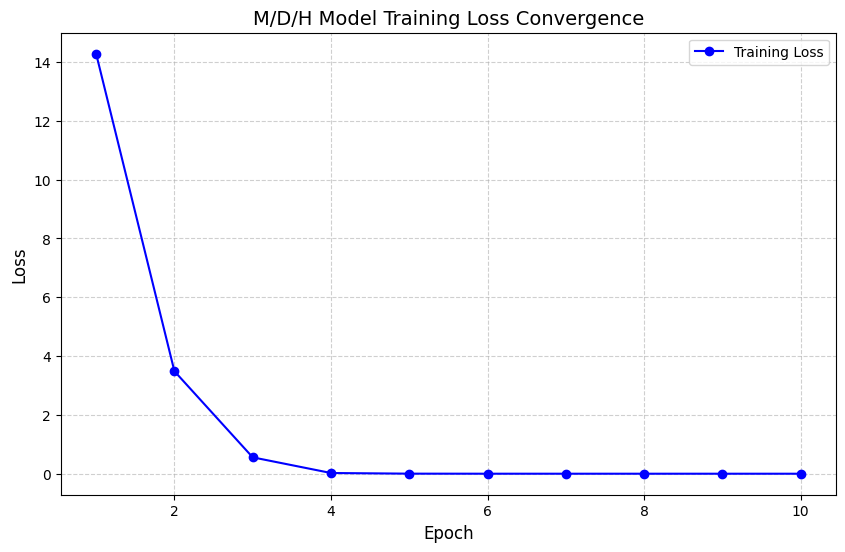

CPU times: user 10 s, sys: 6.18 s, total: 16.2 s
Wall time: 4.5 s


In [ ]:
%%time

import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

# Optimizer 및 Loss 설정
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []

def train_one_epoch(model, train_loader):
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        # m_items: 1달치, d_items: 7일치, h_items: 10분치 (시퀀스)
        # pos_item: 유저가 실제로 구매/클릭한 다음 상품
        # neg_items: 유저가 선택하지 않은 대조군 상품들
        m, d, h, pos_item, neg_items = batch 
        
        optimizer.zero_grad()
        
        # 유저 통합 벡터 생성 (M + D + H)
        user_vec = model(m, d, h) # [Batch, Embed_Dim]
        
        # 상품 벡터 추출 (Shared Item Encoder)
        pos_vec = model.item_embedding(pos_item) # [Batch, Embed_Dim]
        neg_vecs = model.item_embedding(neg_items) # [Batch, Num_Neg, Embed_Dim]
        
        # BPR Loss 계산
        # 정답 상품과의 유사도 (Positive Score)
        pos_score = torch.sum(user_vec * pos_vec, dim=-1)
        
        # 오답 상품들과의 유사도 (Negative Scores)
        neg_scores = torch.bmm(neg_vecs, user_vec.unsqueeze(2)).squeeze()
        
        # 정답은 높게, 오답은 낮게 학습
        loss = -torch.mean(F.logsigmoid(pos_score - neg_scores.max(dim=1)[0]))
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(train_loader)

for epoch in range(1, 11):
    avg_loss = train_one_epoch(model, train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch}: Loss = {avg_loss:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), loss_history, marker='o', color='b', label='Training Loss')
plt.title('M/D/H Model Training Loss Convergence', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# 3. ONNX 변환

In [ ]:
%%time

# 실시간 서빙용 H-Encoder만 추출
h_encoder_only = model.h_encoder
h_encoder_only.eval()

# ONNX 변환 위한 Dummy Input 생성

dummy_input = torch.randn(1, 10, 128)  # [Batch_Size, Sequence_Length, Embedding_Dim]

# ONNX 파일 저장
torch.onnx.export(
    h_encoder_only,
    dummy_input,
    "./h_user_encoder.onnx",
    export_params=True,        # 모델 가중치 포함
    opset_version=12,          # 표준 호환성 버전
    do_constant_folding=True,
    input_names=['input_seq'], # 입력 이름 지정
    output_names=['h_vector'], # 출력 이름 지정
    dynamic_axes={'input_seq': {1: 'seq_length'}} # 가변 시퀀스 길이 허용
)

<timed exec>:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
/Users/eunji.yeom/Desktop/Gigi/projects/rec_emb_template_test/venv/lib/python3.9/site-packages/torch/onnx/symbolic_opset9.py:4244: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with GRU can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as in

CPU times: user 78.6 ms, sys: 25.9 ms, total: 105 ms
Wall time: 1.67 s


In [10]:
print(dummy_input.shape)
print(dummy_input[0][0])

torch.Size([1, 10, 128])
tensor([-0.2301, -0.1660, -0.9697, -0.2725,  0.8159, -0.4490, -0.1369,  0.4039,
        -0.2857, -1.3978,  0.0864,  0.9436,  0.6871, -0.9692,  1.0849, -0.0933,
        -1.0318,  1.0443,  0.3714, -1.0533, -0.4572, -1.1984, -1.4147, -1.3292,
        -0.1451,  0.6276, -0.8063, -0.0035,  1.0830, -0.2405,  0.2294,  0.4173,
        -0.1379,  0.9332,  0.1573,  1.0636,  0.8488,  0.6569, -1.3743,  0.9061,
         0.4984, -1.5558, -0.2618, -0.5304,  0.2625, -0.6341,  0.7170, -1.0789,
        -1.1405, -0.1560,  1.9271,  1.1238, -0.0328, -0.2839,  0.9372,  0.9166,
        -0.0374,  0.2301,  1.9251,  0.2999,  1.0938,  0.9578,  1.3410, -1.1900,
        -1.9036, -1.0294,  0.8806,  1.1161, -0.5467, -0.0773,  0.7046, -0.5523,
         0.3320,  0.0422, -0.4967, -0.1718,  0.8256, -1.2790, -1.2436, -0.4673,
        -0.5954,  0.4227, -0.0471,  0.3689, -0.9654, -0.2017, -0.0666, -0.0605,
         1.3442, -1.3558, -0.5870, -1.2853,  0.6240,  2.1773, -2.1119,  1.3505,
        -0.1799

# 4. 실시간 H-Vector 생성 로직
 - 유저가 클릭했을 때 Inference 수행되는 로직
 - 모델 전체를 돌리지 않고 H User Encoder만 활용

In [ ]:
import onnxruntime as ort
import numpy as np

# Feature Store에 있는 아이템 벡터 테이블 (Online / Redis 가정)
item_vector_table = { 
    "item_A": torch.randn(128), 
    "item_B": torch.randn(128),
    "item_C": torch.randn(128) 
}

# ONNX 모델 로드
onnx_session = ort.InferenceSession(
    "./h_user_encoder.onnx",
    providers=["CPUExecutionProvider"]
    # providers=["CPUExecutionProvider"] # GPU 사용시 활성화
)

def get_realtime_h_vector_onnx(user_clicked_item_ids):
    # Feature Store에서 유저가 클릭한 item vector lookup
    seq_vectors = [item_vector_table[idx] for idx in user_clicked_item_ids]
    seq_tensor = torch.stack(seq_vectors).unsqueeze(0)  # (1, Seq_Len, Embed_Dim)
    input_np = seq_tensor.numpy().astype(np.float32)
    
    # ONNX Inference
    outputs = onnx_session.run(
        None,
        {"input_seq": input_np}
    )
    h_vector = outputs[1].squeeze()
    return h_vector

# EX. 유저가 item_A, item_B을 클릭했다면?
current_h_intent = get_realtime_h_vector_onnx(["item_A", "item_B"])
print(f"실시간 생성된 H 벡터 크기: {current_h_intent.shape}")
print(f"H 벡터 샘플 (처음 5개): {current_h_intent[:5]}")

실시간 생성된 H 벡터 크기: (128,)
H 벡터 샘플 (처음 5개): [-0.1894206   0.19436058 -0.3924984  -0.1023353  -0.0670828 ]


In [ ]:
# 결과 검증) PyTorch 결과와 일치 여부  비교
h_encoder_module = model.h_encoder
with torch.no_grad():
    seq_vectors = [item_vector_table["item_A"], item_vector_table["item_B"]]
    seq_tensor = torch.stack(seq_vectors).unsqueeze(0)
    _, h_pytorch = h_encoder_module(seq_tensor)
    h_pytorch = h_pytorch.squeeze().numpy()

diff = np.abs(current_h_intent - h_pytorch).max()
print(f"PyTorch vs ONNX 최대 차이: {diff:.6f}")

PyTorch vs ONNX 최대 차이: 0.000000


# OpenSearch 색인

In [21]:
%%time

from opensearchpy import OpenSearch


# OpenSearch DEV 클라이언트 생성
host = 'vpc-search-3oreega36l6fakz4w6wjkbk3ee.ap-northeast-2.es.amazonaws.com'
port = 443
auth = ('admin', 'Kurly123!@')

client = OpenSearch(
    hosts=[{'host': host, 'port': port}],
    http_auth=auth,
    use_ssl=True,
    verify_certs=False,
    ssl_show_warn=False
)

index_name = "kurly-user_emb-template-test"
document_id = "2"

document_body = {
    "user_id": "user_002",
    "user_vector": current_h_intent.tolist()
}

response = client.index(
    index=index_name,
    body=document_body,
    id=document_id,
    refresh=True # 즉시 검색 가능하도록 갱신
)

print(f"결과: {response['result']}")
print(f"문서 ID: {response['_id']}")

결과: updated
문서 ID: 2
CPU times: user 5.45 ms, sys: 2.45 ms, total: 7.9 ms
Wall time: 159 ms


# OpenSearch 검색

In [22]:
%%time

search_query = {
    "size": 5,
    "query": {
        "knn": {
            "user_vector": {
                "vector": current_h_intent.tolist(),
                "k": 5
            }
        }
    }
}

try:
    response = client.search(
        body=search_query,
        index=index_name
    )

    print(f"검색 완료! 소요 시간: {response['took']}ms")
    print("-" * 30)

    for hit in response['hits']['hits']:
        score = hit['_score']
        user_id = hit['_source'].get('user_id', 'N/A')
        doc_id = hit['_id']
        print(f"ID: {doc_id} | User: {user_id} | Score: {score}")

except Exception as e:
    print(f"검색 중 에러 발생: {e}")

검색 완료! 소요 시간: 2ms
------------------------------
ID: 2 | User: user_002 | Score: 1.0
ID: 1 | User: user_001 | Score: 0.47505295
CPU times: user 1.1 ms, sys: 1.06 ms, total: 2.16 ms
Wall time: 22 ms
